## 1. Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 4)

## 2. Cargar los datos
El código busca el archivo en la carpeta `/data` del repositorio. Si no lo encuentra (por ejemplo, en Google Colab), lo descarga directamente desde GitHub.

In [2]:
import os

ARCHIVO = "datos_simulados_empleo_sin_experiencia.csv"
URL_GITHUB = "https://raw.githubusercontent.com/samuelvelez1003/Busqueda-Empleo/main/Data/" + ARCHIVO

for ruta in ["../data/" + ARCHIVO, "data/" + ARCHIVO, ARCHIVO]:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta)
        print("Datos cargados desde:", ruta)
        break
else:
    df = pd.read_csv(URL_GITHUB)
    print("Datos cargados desde GitHub")

df.head()

Datos cargados desde GitHub


,id_persona,anio,mes,edad,sexo,ciudad,nivel_educativo,area_formacion,tuvo_practica,cursos_cortos,meses_buscando,sector_aspirado,consiguio_empleo,tipo_contrato,empleo_formal,salario_mensual_cop,fuente
0,P0001,2025,4,27,Hombre,Medellín,Tecnólogo,Contabilidad y finanzas,Sí,2.0,4.0,Industria manufacturera,0,NaN,NaN,NaN,SIMULADO
1,P0002,2025,3,24,Mujer,Manizales,Técnico,Mecánica y electricidad,Sí,1.0,3.0,Atención al cliente / call center,1,Obra o labor,Sí,2096000.0,SIMULADO
2,P0003,2025,1,19,Hombre,Medellín,Tecnólogo,Contabilidad y finanzas,Sí,3.0,10.0,Industria manufacturera,0,NaN,NaN,NaN,SIMULADO
3,P0004,2025,12,21,Hombre,Bogotá,Bachiller,Ninguna,No,0.0,12.0,Servicios financieros,0,NaN,NaN,NaN,SIMULADO
4,P0005,2025,5,24,Hombre,Medellín,Técnico,Salud,Sí,2.0,4.0,Construcción,1,Indefinido,Sí,1989000.0,SIMULADO


## 3. Tamaño y tipos de datos

In [3]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 1200
Columnas: 17


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_persona           1200 non-null   object 
 1   anio                 1200 non-null   int64  
 2   mes                  1200 non-null   int64  
 3   edad                 1200 non-null   int64  
 4   sexo                 1200 non-null   object 
 5   ciudad               1200 non-null   object 
 6   nivel_educativo      1200 non-null   object 
 7   area_formacion       1190 non-null   object 
 8   tuvo_practica        1200 non-null   object 
 9   cursos_cortos        1182 non-null   float64
 10  meses_buscando       1175 non-null   float64
 11  sector_aspirado      1200 non-null   object 
 12  consiguio_empleo     1200 non-null   int64  
 13  tipo_contrato        751 non-null    object 
 14  empleo_formal        751 non-null    object 
 15  salario_mensual_cop  751 non-null    f

**Diccionario rápido de variables**

| Variable | Descripción |
|---|---|
| `id_persona` | Identificador de la persona |
| `anio`, `mes` | Periodo del registro (2025) |
| `edad`, `sexo`, `ciudad` | Datos básicos de la persona |
| `nivel_educativo`, `area_formacion` | Formación alcanzada |
| `tuvo_practica`, `cursos_cortos` | Preparación adicional |
| `meses_buscando` | Tiempo buscando empleo |
| `sector_aspirado` | Sector donde busca trabajo |
| `consiguio_empleo` | **Variable objetivo**: 1 = sí, 0 = no |
| `tipo_contrato`, `empleo_formal`, `salario_mensual_cop` | Solo para quienes consiguieron empleo |

## 4. Datos faltantes

In [5]:
faltantes = df.isna().sum().to_frame("faltantes")
faltantes["porcentaje"] = (faltantes["faltantes"] / len(df) * 100).round(1)
faltantes[faltantes["faltantes"] > 0].sort_values("faltantes", ascending=False)

,faltantes,porcentaje
empleo_formal,449,37.4
tipo_contrato,449,37.4
salario_mensual_cop,449,37.4
meses_buscando,25,2.1
cursos_cortos,18,1.5
area_formacion,10,0.8


**Interpretación:** `tipo_contrato`, `empleo_formal` y `salario_mensual_cop` están vacíos cuando la persona **no** consiguió empleo, así que esos vacíos son esperados. Los faltantes de `meses_buscando`, `cursos_cortos` y `area_formacion` sí se deben tratar en el notebook de limpieza.

## 5. Estadísticas descriptivas

In [6]:
df.describe().round(1)

,anio,mes,edad,cursos_cortos,meses_buscando,consiguio_empleo,salario_mensual_cop
count,1200.0,1200.0,1200.0,1182.0,1175.0,1200.0,751.0
mean,2025.0,6.5,23.6,1.2,5.3,0.6,1683237.0
std,0.0,3.5,3.1,1.1,4.2,0.5,485036.4
min,2025.0,1.0,18.0,0.0,0.0,0.0,645000.0
25%,2025.0,3.8,21.0,0.0,2.0,0.0,1319500.0
50%,2025.0,6.0,24.0,1.0,4.0,1.0,1633000.0
75%,2025.0,10.0,26.0,2.0,7.0,1.0,1996500.0
max,2025.0,12.0,28.0,6.0,24.0,1.0,3583000.0


In [7]:
df.describe(include="object")

,id_persona,sexo,ciudad,nivel_educativo,area_formacion,tuvo_practica,sector_aspirado,tipo_contrato,empleo_formal,fuente
count,1200,1200,1200,1200,1190,1200,1200,751,751,1200
unique,1200,2,10,4,15,2,10,6,2,1
top,P1184,Mujer,Bogotá,Bachiller,Ninguna,No,Industria manufacturera,Término fijo,Sí,SIMULADO
freq,1,613,319,376,372,732,137,200,589,1200


## 6. Variable objetivo: ¿consiguió empleo?

Porcentaje que consiguió empleo: 62.6%


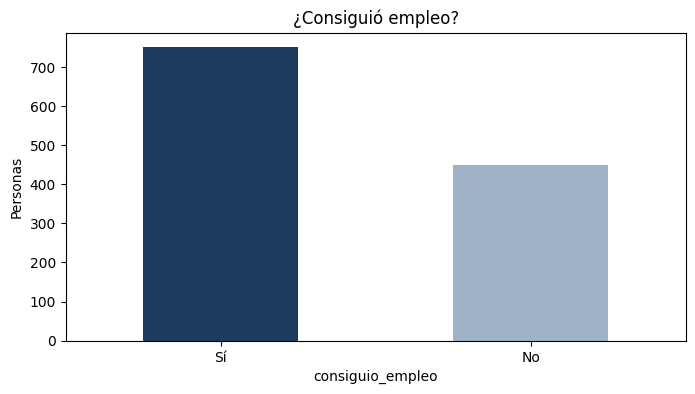

In [8]:
tasa = df["consiguio_empleo"].mean() * 100
print(f"Porcentaje que consiguió empleo: {tasa:.1f}%")

df["consiguio_empleo"].map({1: "Sí", 0: "No"}).value_counts().plot(kind="bar", color=["#1F3A5F", "#9FB3C8"])
plt.title("¿Consiguió empleo?")
plt.ylabel("Personas")
plt.xticks(rotation=0)
plt.show()

## 7. Primeros patrones
Se calcula el **porcentaje de jóvenes que consiguió empleo** en cada grupo. Esto permite una primera revisión de la hipótesis: *la formación técnica/tecnológica y el sector influyen en conseguir el primer empleo.*

In [9]:
def tasa_empleo(columna):
    tabla = (df.groupby(columna)["consiguio_empleo"]
               .agg(personas="count", tasa_empleo="mean")
               .sort_values("tasa_empleo", ascending=False))
    tabla["tasa_empleo"] = (tabla["tasa_empleo"] * 100).round(1)
    return tabla

def grafica_tasa(columna, titulo):
    t = tasa_empleo(columna)["tasa_empleo"].sort_values()
    t.plot(kind="barh", color="#1F3A5F")
    plt.title(titulo)
    plt.xlabel("% que consiguió empleo")
    plt.ylabel("")
    plt.show()

### 7.1 Por nivel educativo

,personas,tasa_empleo
nivel_educativo,,
Tecnólogo,213,73.7
Técnico,288,70.8
Universitario,323,61.3
Bachiller,376,51.1


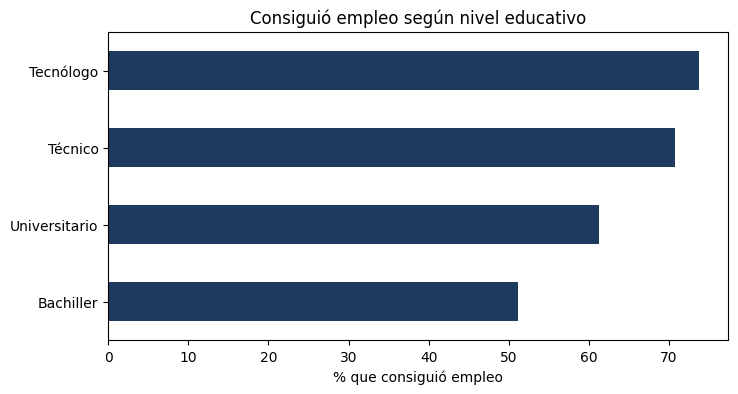

In [10]:
display(tasa_empleo("nivel_educativo"))
grafica_tasa("nivel_educativo", "Consiguió empleo según nivel educativo")

### 7.2 Según si tuvo práctica

,personas,tasa_empleo
tuvo_practica,,
Sí,468,73.5
No,732,55.6


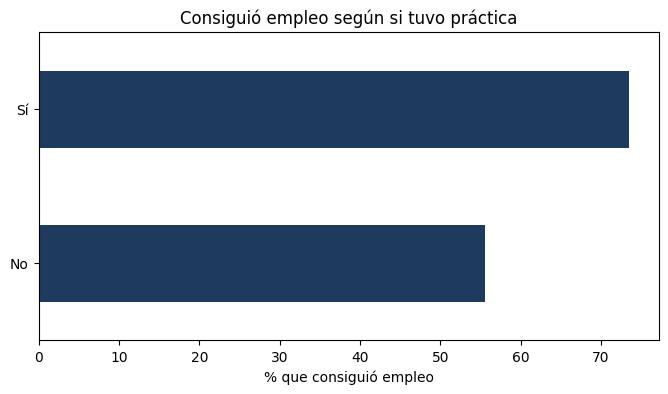

In [11]:
display(tasa_empleo("tuvo_practica"))
grafica_tasa("tuvo_practica", "Consiguió empleo según si tuvo práctica")

### 7.3 Por sector al que aspira

,personas,tasa_empleo
sector_aspirado,,
Atención al cliente / call center,119,69.7
Comercio,128,68.0
Logística y transporte,110,65.5
Industria manufacturera,137,65.0
Construcción,113,62.8
Tecnología,110,62.7
Hotelería y restaurantes,125,60.8
Servicios financieros,120,58.3
Educación,126,57.1


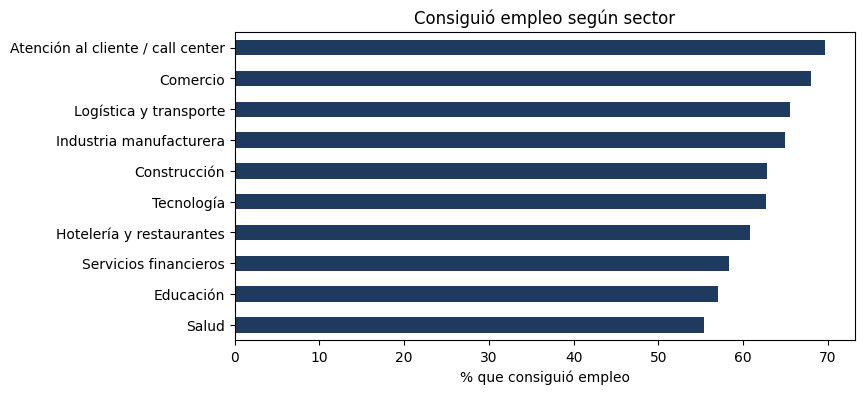

In [12]:
display(tasa_empleo("sector_aspirado"))
grafica_tasa("sector_aspirado", "Consiguió empleo según sector")

### 7.4 Por ciudad

,personas,tasa_empleo
ciudad,,
Pereira,83,68.7
Pasto,43,67.4
Medellín,179,67.0
Bogotá,319,65.5
Cartagena,73,63.0
Bucaramanga,107,61.7
Cali,151,60.3
Manizales,74,58.1
Ibagué,57,54.4


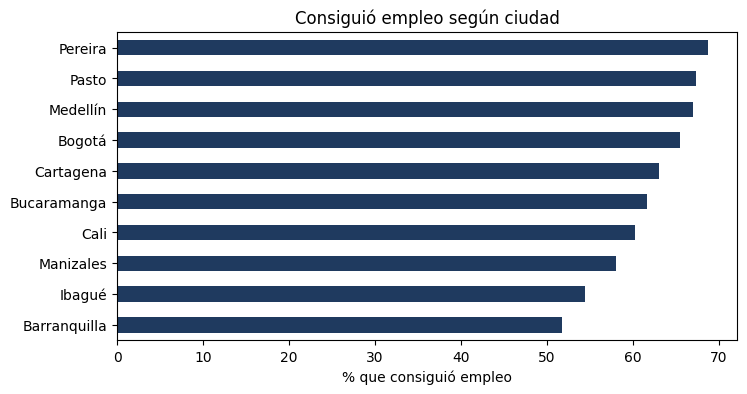

In [13]:
display(tasa_empleo("ciudad"))
grafica_tasa("ciudad", "Consiguió empleo según ciudad")

### 7.5 Edad

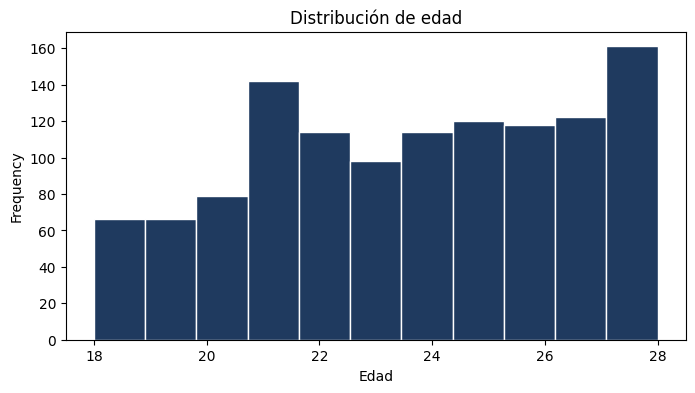

In [14]:
df["edad"].plot(kind="hist", bins=11, color="#1F3A5F", edgecolor="white")
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.show()

### 7.6 Salario de quienes consiguieron empleo

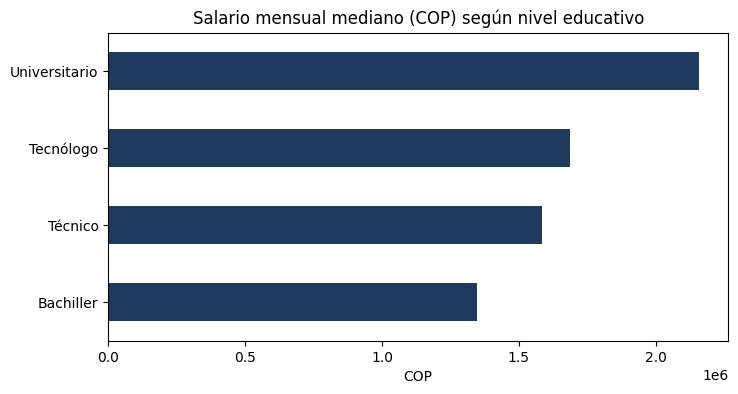

Porcentaje con empleo formal: 78.4 %


In [15]:
ocupados = df[df["consiguio_empleo"] == 1]
(ocupados.groupby("nivel_educativo")["salario_mensual_cop"]
         .median().sort_values().plot(kind="barh", color="#1F3A5F"))
plt.title("Salario mensual mediano (COP) según nivel educativo")
plt.xlabel("COP")
plt.ylabel("")
plt.show()

print("Porcentaje con empleo formal:", round((ocupados["empleo_formal"] == "Sí").mean() * 100, 1), "%")